In [ ]:
!pip install boto3
import os
import boto3
import pandas as pd
import glob
import json
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, classification_report

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.9 MB/s eta 0:00:00



## Key Metrics (Positive Class: Readmission='Yes')
- **Precision:** 0.8824 ($rac{TP}{TP + FP}$)
- **Recall:** 0.9375 ($rac{TP}{TP + FN}$)
✅ Confusion Matrix plot saved as 'confusion_matrix_plot.png'


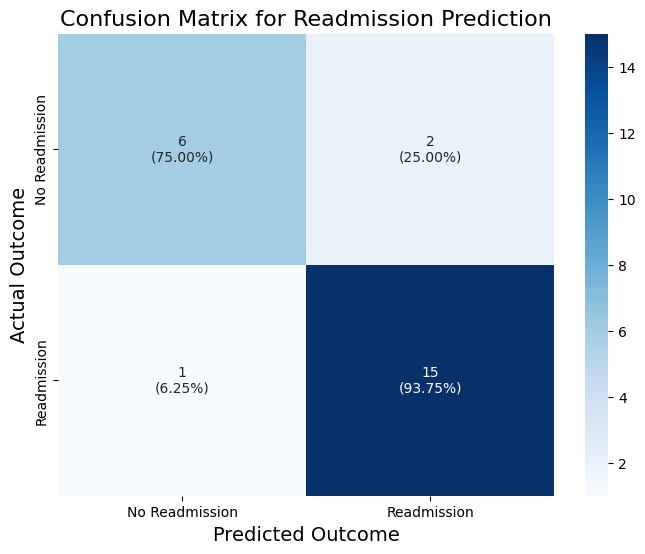

In [ ]:

file_name = "readmission_predictions_final.csv"
df = pd.read_csv(file_name)
df.dropna(subset=['actual_readmission', 'pred_readmission'], inplace=True)

y_true = df['actual_readmission'].map({'Yes': 1, 'No': 0}).dropna().astype(int)
y_pred = df['pred_readmission'].map({'Yes': 1, 'No': 0}).dropna().astype(int)

aligned_df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred}).dropna()
y_true = aligned_df['y_true']
y_pred = aligned_df['y_pred']

precision = precision_score(y_true, y_pred, pos_label=1)
recall = recall_score(y_true, y_pred, pos_label=1)

print("\n## Key Metrics (Positive Class: Readmission='Yes')")
print(f"- **Precision:** {precision:.4f} ($\frac{{TP}}{{TP + FP}}$)")
print(f"- **Recall:** {recall:.4f} ($\frac{{TP}}{{TP + FN}}$)")

if y_true.empty:
    print("Error: After cleaning, no valid data remains for plotting.")
    raise ValueError("Empty data.")

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Row-normalize (Recall)

labels = ['No Readmission', 'Readmission']

group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["({0:.2%})".format(value) for value in cm_normalized.flatten()]

box_labels = [f"{c}\n{p}" for c, p in zip(group_counts, group_percentages)]
box_labels = np.asarray(box_labels).reshape(2, 2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=box_labels,
            fmt="",
            cmap='Blues',
            cbar=True,
            xticklabels=labels,
            yticklabels=labels)
plt.title('Confusion Matrix for Readmission Prediction', fontsize=16)
plt.ylabel('Actual Outcome', fontsize=14)
plt.xlabel('Predicted Outcome', fontsize=14)

output_plot_filename = "confusion_matrix_plot.png"
plt.savefig(output_plot_filename)
print(f"✅ Confusion Matrix plot saved as '{output_plot_filename}'")